In [1]:
import pandas as pd
import numpy as np


In [2]:
# Load data
X = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/X_encoded.csv")
y = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/y.csv").values.ravel()

# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [3]:
# Load test data
X_test_final = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/X_test_encoded.csv")

# Predict
predictions_log = model.predict(X_test_final)

# Convert back
predictions = np.exp(predictions_log)

In [4]:
# Load test IDs
test_ids = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/test_clean.csv")["Id"]

# Create submission
Prediction = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

In [5]:

# Save
Prediction.to_csv("prediction.csv", index=False)

print("Prediction file created!")

Prediction file created!


In [6]:
# Show first rows
print(Prediction.head())

# Show shape
print("Prediction shape:", Prediction.shape)

     Id      SalePrice
0  1461   93731.175666
1  1462  129684.730745
2  1463  143074.688350
3  1464  154488.114028
4  1465  151009.679009
Prediction shape: (1459, 2)


In [7]:
Prediction.head(10)

,Id,SalePrice
0,1461,93731.175666
1,1462,129684.730745
2,1463,143074.688350
3,1464,154488.114028
4,1465,151009.679009
5,1466,132351.172214
6,1467,139955.099725
7,1468,124303.155098
8,1469,149973.820125
9,1470,93710.301882


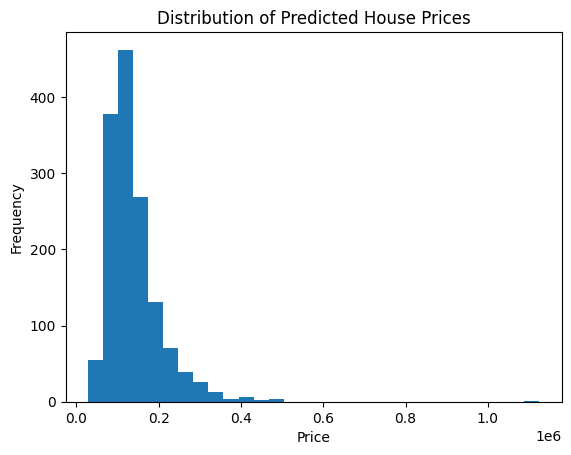

In [8]:
import matplotlib.pyplot as plt

plt.hist(predictions, bins=30)
plt.title("Distribution of Predicted House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

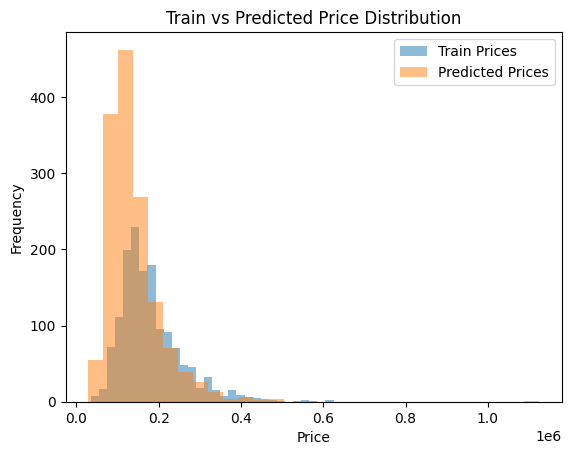

In [9]:
# Load original SalePrice (before log)
train_original = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/train_clean.csv")

# Convert back (important)
train_prices = np.exp(train_original["SalePrice"])

plt.hist(train_prices, bins=30, alpha=0.5, label="Train Prices")
plt.hist(predictions, bins=30, alpha=0.5, label="Predicted Prices")

plt.legend()
plt.title("Train vs Predicted Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Top expensive houses
print("Top predicted prices:")
print(Prediction.sort_values(by="SalePrice", ascending=False).head())

# Cheapest houses
print("Lowest predicted prices:")
print(Prediction.sort_values(by="SalePrice", ascending=True).head())

Top predicted prices:
        Id     SalePrice
1089  2550  1.124749e+06
203   1664  5.032189e+05
803   2264  4.766003e+05
1222  2683  4.716556e+05
514   1975  4.594357e+05
Lowest predicted prices:
        Id     SalePrice
1431  2892  28533.701378
362   1823  32309.090304
1433  2894  36388.537836
453   1914  39782.012610
359   1820  40410.643231


In [11]:
import pandas as pd

# Charger le test original (non encodé)
test = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/test_clean.csv")

In [12]:
full_results = test.copy()
full_results["PredictedPrice"] = predictions

full_results.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,PredictedPrice
0,1461,20,RH,80,11622,Pave,Reg,Lvl,AllPub,Inside,...,Ex,MnPrv,Shed,0,6,2010,WD,Normal,1778,93731.175666
1,1462,20,RL,81,14267,Pave,IR1,Lvl,AllPub,Corner,...,Ex,GdWo,Gar2,12500,6,2010,WD,Normal,2658,129684.730745
2,1463,60,RL,74,13830,Pave,IR1,Lvl,AllPub,Inside,...,Ex,MnPrv,Shed,0,3,2010,WD,Normal,2557,143074.688350
3,1464,60,RL,78,9978,Pave,IR1,Lvl,AllPub,Inside,...,Ex,GdPrv,Shed,0,6,2010,WD,Normal,2530,154488.114028
4,1465,120,RL,43,5005,Pave,IR1,HLS,AllPub,Inside,...,Ex,MnPrv,Shed,0,1,2010,WD,Normal,2560,151009.679009


In [13]:
full_results.sort_values(by="PredictedPrice", ascending=False).head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,PredictedPrice
1089,2550,20,RL,128,39290,Pave,IR1,Bnk,AllPub,Inside,...,Ex,GdPrv,Shed,17000,10,2007,New,Partial,10190,1.124749e+06
203,1664,20,RL,105,13693,Pave,Reg,Lvl,AllPub,Inside,...,Ex,GdWo,Shed,0,3,2009,WD,Normal,5304,5.032189e+05
803,2264,20,RL,52,51974,Pave,IR1,Lvl,AllPub,CulDSac,...,Ex,GdPrv,Shed,0,6,2007,New,Partial,4998,4.766003e+05
1222,2683,60,RL,114,17242,Pave,IR1,Lvl,AllPub,Inside,...,Ex,GdPrv,Shed,0,5,2006,WD,Normal,5233,4.716556e+05
514,1975,20,RL,106,12720,Pave,Reg,HLS,AllPub,Inside,...,Ex,MnPrv,Shed,0,2,2008,WD,Normal,5005,4.594357e+05


In [14]:
full_results.sort_values(by="PredictedPrice", ascending=True).head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,PredictedPrice
1431,2892,30,C (all),69,12366,Pave,Reg,Lvl,AllPub,Inside,...,Ex,GdWo,Shed,0,10,2006,WD,Abnorml,729,28533.701378
362,1823,30,C (all),72,9392,Pave,Reg,Lvl,AllPub,Corner,...,Ex,MnPrv,Shed,0,9,2009,WD,Abnorml,1042,32309.090304
1433,2894,50,C (all),60,8520,Grvl,Reg,Bnk,AllPub,Inside,...,Ex,MnPrv,Shed,0,4,2006,WD,Normal,1152,36388.537836
453,1914,30,C (all),60,10200,Pave,Reg,Lvl,AllPub,Inside,...,Ex,MnPrv,Shed,0,5,2009,WD,Normal,1144,39782.012610
359,1820,30,C (all),56,3300,Pave,Reg,Lvl,AllPub,Inside,...,Ex,MnPrv,Shed,0,6,2009,WD,Normal,1440,40410.643231
